# Credit Card Transaction Analysis Dashboard

Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

     #shapes used to design dashboard elements
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle

Cell 2: Create Dataset & Calculate KPIs

Cell 2: Create Dataset & Calculate KPIs

In [2]:

      # Creating sample dataset for monthly credit card spending

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

spend = np.array([                            # Monthly spending values (USD)
    36000,42000,48000,36500,47000,42500,
    44500,45000,39800,36700,45200,45100
])

categories = ["Shop Online","Personal Care","Home","Entertainment"]    #Category level spending
values = [27540,20870,14200,13510]

df = pd.DataFrame({    # Convert into DataFrame for easier plotting

    "Month": months,
    "Spend": spend
})
       # KPI Calculations
total_spend = spend.sum()    
transactions = 1255
avg_value = total_spend / transactions

Cell 3: Build Dashboard Layout & Export Figure

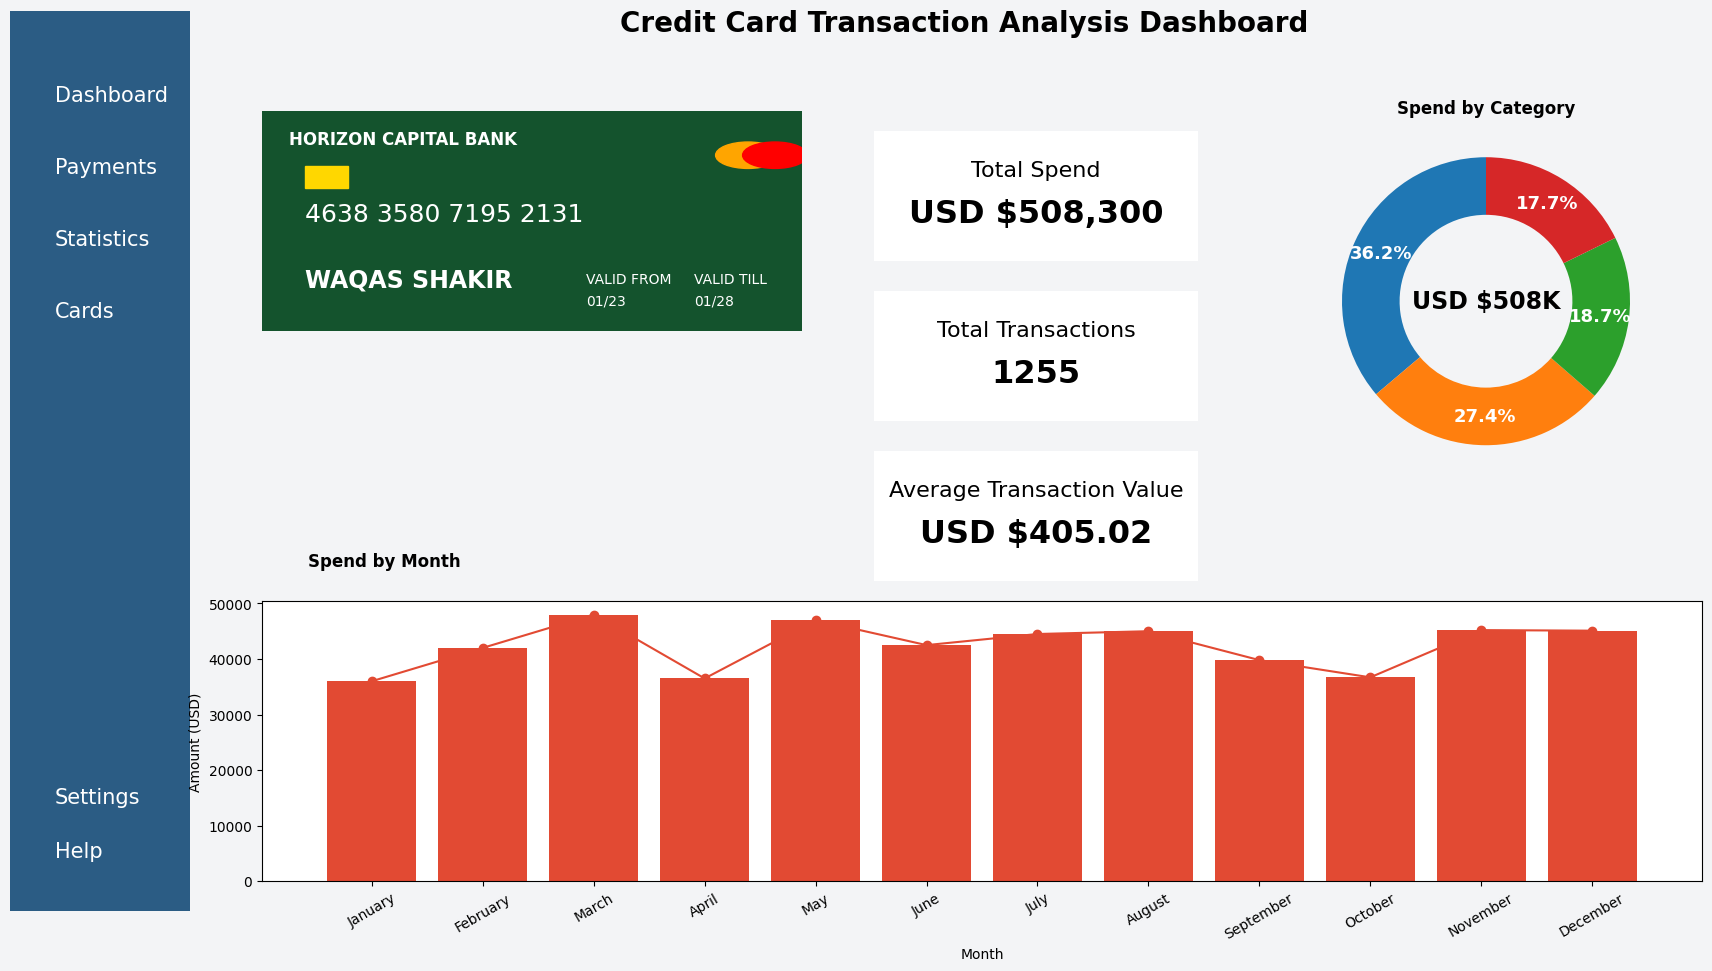

In [3]:
        # Creating Dashboard Layout using Matplotlib
""" This section builds the visual dashboard layout using Matplotlib
    We manually place each component (sidebar, charts, KPI cards) to
    mimic a real analytics dashboard interface. 
"""

fig = plt.figure(figsize=(18,10))     # Create Main Figure
fig.patch.set_facecolor('#f3f4f6')

        # ---------------- Sidebar ----------------

ax_sidebar = fig.add_axes([0.02,0.05,0.10,0.9])
ax_sidebar.axis("off")      # Hide axis lines for cleaner UI

sidebar = FancyBboxPatch(     #Create rounded rectangle sidebar background  
    (0,0),1,1,
    boxstyle= "round,pad=0.02,rounding_size=20",
    facecolor= "#2b5c84"
)

ax_sidebar.add_patch(sidebar)   

  # Sidebar navigation menu items
menu_items = ["Dashboard","Payments","Statistics","Cards"]
y = 0.90

for item in menu_items:    # Loop through menu items and place them vertically

    ax_sidebar.text(0.25,y,item,color="white",fontsize=15)
    y -= 0.08

# Bottom sidebar options
ax_sidebar.text(0.25,0.12,"Settings",color="white",fontsize=15)
ax_sidebar.text(0.25,0.06,"Help",color="white",fontsize=15)


        # ---------------- Title ----------------

fig.text(          # Displays the main heading at the top of the dashboard
    0.55,0.93,
    "Credit Card Transaction Analysis Dashboard",
    ha="center",
    fontsize=20,
    fontweight="bold"
)


        # -------------- Credit Card -------------

ax_card = fig.add_axes([0.16,0.63,0.30,0.22])
ax_card.axis("off")

shadow = FancyBboxPatch(       # Card shadow to create depth effect
    (0.02,-0.02),1,1,
    boxstyle="round,pad=0.02,rounding_size=20",
    alpha=0.3
)

card = FancyBboxPatch(        # Main card body
    (0,0),1,1,
    boxstyle="round,pad=0.02,rounding_size=20",
    facecolor="#14532d"
)

ax_card.add_patch(shadow)
ax_card.add_patch(card)
                          # Bank name
ax_card.text(0.05,0.85,"HORIZON CAPITAL BANK",     
             color="white",fontsize=12,fontweight="bold")

ax_card.text(0.08,0.50,"4638 3580 7195 2131",    # Credit card number          
             color="white",fontsize=18)

ax_card.text(0.08,0.20,"WAQAS SHAKIR",           # Card holder name
             color="white",fontsize=17,fontweight="bold")

ax_card.text(0.60,0.22,"VALID FROM",color="white",fontsize=10)
ax_card.text(0.60,0.12,"01/23",color="white",fontsize=10)

ax_card.text(0.80,0.22,"VALID TILL",color="white",fontsize=10)
ax_card.text(0.80,0.12,"01/28",color="white",fontsize=10)

chip = Rectangle((0.08,0.65),0.08,0.10,color="gold")       # Credit card chip
ax_card.add_patch(chip)

ax_card.add_patch(Circle((0.90,0.80),0.06,color="orange"))    # Payment network circles (Mastercard style)
ax_card.add_patch(Circle((0.95,0.80),0.06,color="red"))


         # -------------- KPI Cards --------------
def kpi(ax,title,value):
    
    ax.axis("off")       # Remove axis visuals
    
    box = FancyBboxPatch(           # Create white card container
        (0,0),1,1,
        boxstyle="round,pad=0.02,rounding_size=15",
        facecolor="#ffffff"
    )
    
    ax.add_patch(box)    
    
    ax.text(0.5,0.65,title,          # KPI title
            ha="center",
            fontsize=16)
    
    ax.text(0.5,0.30,value,          # KPI value
            ha="center",
            fontsize=23,
            fontweight="bold")


ax1 = fig.add_axes([0.50,0.70,0.18,0.13])            # Total Spend KPI
kpi(ax1,"Total Spend",f"USD ${total_spend:,.0f}")

ax2 = fig.add_axes([0.50,0.54,0.18,0.13])            # Total Transactions KPI
kpi(ax2,"Total Transactions",transactions)
 
ax3 = fig.add_axes([0.50,0.38,0.18,0.13])            # Average Transaction KPI
kpi(ax3,"Average Transaction Value",f"USD ${avg_value:,.2f}")


       # -------------- Donut Chart ---------------
            # Shows how spending is distributed across categories

ax_pie = fig.add_axes([0.72,0.48,0.24,0.36])

wedges,texts,autotexts = ax_pie.pie(
    values,
    startangle=90,
    wedgeprops=dict(width=0.40),       # Creates donut shape
    autopct='%1.1f%%',
    pctdistance=0.80
)
 
for t in autotexts:           # Format percentage labels
    t.set_color("white")
    t.set_fontsize(13)
    t.set_weight("bold")

ax_pie.set_title("Spend by Category", fontweight="bold")

ax_pie.text(        # Total spend displayed in center of donut
    0,0,
    f"USD ${total_spend/1000:.0f}K",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)


      # -------------- Spend by Month --------------
            # Bar + line chart showing spending trend across the year

ax_bar = fig.add_axes([0.16,0.08,0.80,0.28])

ax_bar.bar(df["Month"],df["Spend"],color="#e24a33")       # Bar chart for monthly spend
ax_bar.plot(df["Month"],df["Spend"],marker="o",color="#e24a33")   # Line overlay to highlight trend pattern

ax_bar.set_title(
    "        Spend by Month",
    loc="left",
    pad=25,
    fontweight="bold"
)

ax_bar.set_ylabel("Amount (USD)")
ax_bar.set_xlabel("Month")

plt.xticks(rotation=30)       # Rotate month labels for better readability

 
plt.savefig(                      # Save  Dashboard Image
    "credit_card_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()      # Display dashboard
